# Starbucks: Local Search Advertising on Google Maps

Phillips ran a randomized pilot test across 200 markets (100 treatment, 100 control) from January to December. Local search ads on Google Maps were only active in treatment markets during June–December. The goal is to measure whether those ads actually moved the needle on unit sales.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('starbucks.csv')

df['post'] = (df['month'] >= 6).astype(int)
df['treated_post'] = df['treatment'] * df['post']

print(f"Dataset: {df.shape[0]:,} observations, {df['geo_ID'].nunique()} markets, {df['month'].nunique()} months")
print(f"Treatment markets: {df[df['treatment']==1]['geo_ID'].nunique()} | Control markets: {df[df['treatment']==0]['geo_ID'].nunique()}")
df.head()

Dataset: 2,400 observations, 200 markets, 12 months
Treatment markets: 100 | Control markets: 100


,geo_ID,geo_name,month,sales,price,treatment,age_21over_pct,age_55over_pct,age_85over_pct,race_native_pct,race_asian_pct,race_black_pct,race_hispanic_pct,race_white_pct,unemployed_pct,incomeK,post,treated_post
0,1,Portland ME,1,80.495,2.9269,1,72.61,25.06,1.05,0.57,6.35,6.31,3.79,84.78,5.64,40.88,0,0
1,1,Portland ME,2,106.500,2.7980,1,72.47,25.10,0.99,0.48,6.76,6.90,3.78,85.67,5.54,40.15,0,0
2,1,Portland ME,3,78.382,3.0511,1,73.01,25.13,1.15,0.60,7.01,6.28,3.48,83.55,5.58,39.93,0,0
3,1,Portland ME,4,110.250,3.0942,1,72.41,25.02,0.98,0.47,6.52,6.70,4.40,83.60,5.24,40.23,0,0
4,1,Portland ME,5,135.150,2.9836,1,72.43,25.21,0.98,0.50,6.39,6.07,3.65,84.75,5.24,41.20,0,0


---
## Q.1: What modeling approach is best suited for this task?

The right approach here is a Difference-in-Differences (DiD) regression.

Phillips set up the experiment with two dimensions of variation built in: a treatment vs. control split across markets, and a before vs. after split in time (January–May as pre, June–December as post). DiD would be perfect for this structure, it isolates the causal effect of the ads by comparing how much treatment markets changed relative to how much control markets changed over the same period.
Also, a simple comparison of treatment vs. control in the post period would be misleading if the two groups started at different baseline sales levels. DiD controls for that by using the pre-period as a benchmark. It also removes any time trends that affect all markets equally (like seasonal sales patterns), since those would show up in both groups and cancel out in the difference.

## Q.2 Conduct the analysis

Check for: (1) treatment and control markets had similar baseline sales in the pre-period, and (2) they were trending similarly before the ads went live.

If the parallel trends assumption fails, the DiD estimate is not valid.

In [ ]:
# Pre-period balance check
pre = df[df['post'] == 0]
t_pre = pre[pre['treatment'] == 1]['sales']
c_pre = pre[pre['treatment'] == 0]['sales']
t_stat, p_val = stats.ttest_ind(t_pre, c_pre)

print("=== Pre-Period Sales Balance ===")
print(f"Treatment mean: {t_pre.mean():.2f}")
print(f"Control mean:   {c_pre.mean():.2f}")
print(f"Difference:     {t_pre.mean() - c_pre.mean():.2f}")
print(f"t-test p-value: {p_val:.4f}")

=== Pre-Period Sales Balance ===
Treatment mean: 121.46
Control mean:   120.06
Difference:     1.41
t-test p-value: 0.2713


The pre-period means are close and the difference is not statistically significant (p=0.27). The randomization is verified both groups started from a comparable baseline.

In [ ]:
# Parallel trends: test whether the pre-period trend differs between groups
# If treatment x month is not significant, the groups were moving in parallel before ads

def ols_hc3(X_arr, y_arr, names):
    """OLS with HC3 heteroskedasticity-robust standard errors."""
    n, k = X_arr.shape
    b = np.linalg.lstsq(X_arr, y_arr, rcond=None)[0]
    resid = y_arr - X_arr @ b
    H = X_arr @ np.linalg.pinv(X_arr.T @ X_arr) @ X_arr.T
    h = np.clip(np.diag(H), 0, 0.9999)
    e2 = (resid / (1 - h)) ** 2
    meat = X_arr.T @ np.diag(e2) @ X_arr
    bread = np.linalg.pinv(X_arr.T @ X_arr)
    se = np.sqrt(np.diag(bread @ meat @ bread))
    t_stats = b / se
    p_vals = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))
    results = pd.DataFrame({'coef': b, 'se': se, 't': t_stats, 'p': p_vals}, index=names)
    return results

pre_df = df[df['post'] == 0].copy()
X_trends = np.column_stack([
    np.ones(len(pre_df)),
    pre_df['treatment'],
    pre_df['month'],
    pre_df['treatment'] * pre_df['month']
])
res_trends = ols_hc3(X_trends, pre_df['sales'].values,
                     ['intercept', 'treatment', 'month', 'treatment x month'])

print("=== Parallel Trends Test (pre-period only) ===")
print(res_trends.round(4).to_string())

=== Parallel Trends Test (pre-period only) ===
                       coef      se        t       p
intercept          112.8910  2.1350  52.8763  0.0000
treatment            2.4829  2.9404   0.8444  0.3986
month                2.3889  0.6548   3.6482  0.0003
treatment x month   -0.3588  0.8910  -0.4027  0.6873


The treatment x month interaction is not significant (p=0.69).
Both groups were trending at essentially the same rate before the ads went live.
The parallel trends assumption passes.

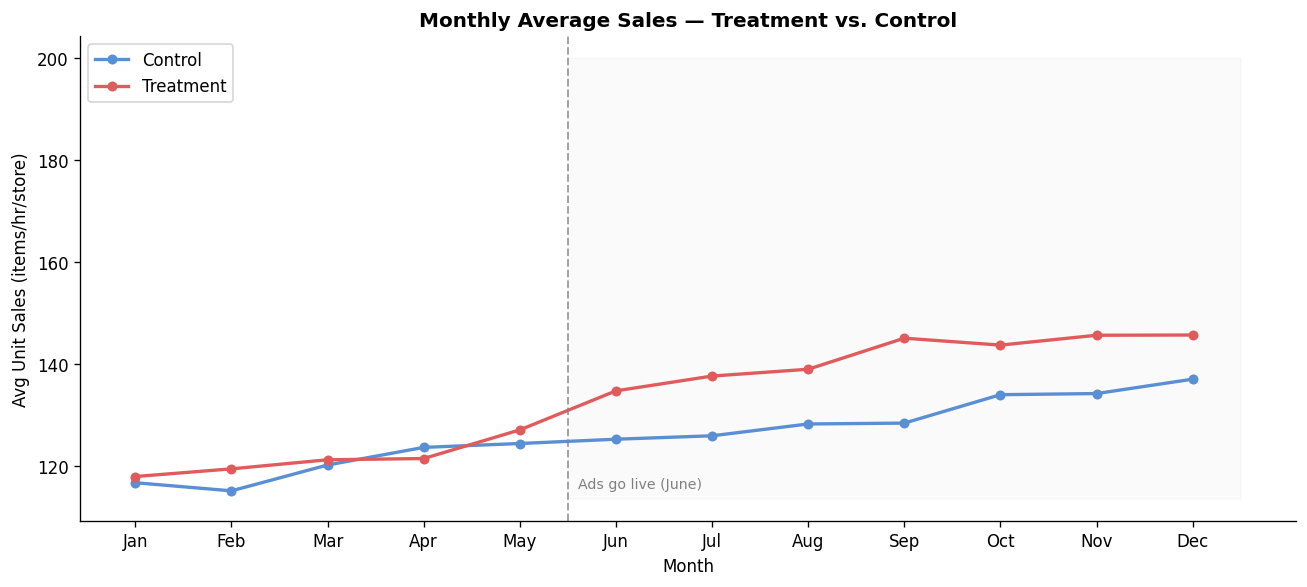

In [ ]:
# Visual: monthly sales trends by group
monthly = df.groupby(['month', 'treatment'])['sales'].mean().reset_index()
ctrl = monthly[monthly['treatment'] == 0]
trt  = monthly[monthly['treatment'] == 1]

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(ctrl['month'], ctrl['sales'], color='#5b8fd4', lw=2, marker='o', ms=5, label='Control')
ax.plot(trt['month'],  trt['sales'],  color='#e05c5c', lw=2, marker='o', ms=5, label='Treatment')

ax.axvline(5.5, color='gray', lw=1.2, linestyle='--', alpha=0.7)
ax.text(5.6, ax.get_ylim()[0] + 2, 'Ads go live (June)', fontsize=8.5, color='gray')
ax.fill_betweenx([ax.get_ylim()[0], 200], 5.5, 12.5, alpha=0.04, color='gray')

ax.set_xlabel('Month')
ax.set_ylabel('Avg Unit Sales (items/hr/store)')
ax.set_title('Monthly Average Sales — Treatment vs. Control', fontsize=12, fontweight='bold')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()
plt.tight_layout()
plt.show()

The chart shows the two groups tracking closely in the pre-period (Jan-May),
then diverging clearly once the ads launch in June. That's the pattern we can use DiD quantify.

### 2b. Difference-in-Differences Regression

In [ ]:
# Model 1: Basic DiD
X1 = np.column_stack([
    np.ones(len(df)),
    df['treatment'],
    df['post'],
    df['treated_post']
])
res1 = ols_hc3(X1, df['sales'].values, ['intercept', 'treatment', 'post', 'treated_post'])

print("=== Model 1: Basic DiD ===")
print(res1.round(4).to_string())
print()

did_est = res1.loc['treated_post', 'coef']
did_p   = res1.loc['treated_post', 'p']
print(f"DiD estimate (treated_post): {did_est:.4f}")
print(f"p-value: {did_p:.4f}")

=== Model 1: Basic DiD ===
                  coef      se         t       p
intercept     120.0576  0.9208  130.3821  0.0000
treatment       1.4067  1.2793    1.0996  0.2716
post           10.4085  1.2114    8.5920  0.0000
treated_post    9.7877  1.7229    5.6811  0.0000

DiD estimate (treated_post): 9.7877
p-value: 0.0000


In [ ]:
# Model 2: DiD with demographic and market controls
covs = ['age_21over_pct', 'age_55over_pct', 'race_asian_pct', 'race_black_pct',
        'race_hispanic_pct', 'race_white_pct', 'unemployed_pct', 'incomeK']

X2 = np.column_stack([
    np.ones(len(df)),
    df['treatment'],
    df['post'],
    df['treated_post'],
    df[covs].values
])
names2 = ['intercept', 'treatment', 'post', 'treated_post'] + covs
res2 = ols_hc3(X2, df['sales'].values, names2)

print("=== Model 2: DiD with Controls ===")
print(res2.round(4).to_string())
print()
print(f"DiD estimate with controls: {res2.loc['treated_post','coef']:.4f}")
print(f"p-value: {res2.loc['treated_post','p']:.4f}")

=== Model 2: DiD with Controls ===
                       coef       se       t       p
intercept          140.1667  19.7541  7.0956  0.0000
treatment            1.4594   1.3010  1.1218  0.2621
post                10.4104   1.2142  8.5736  0.0000
treated_post         9.7858   1.7250  5.6728  0.0000
age_21over_pct       0.1583   0.1749  0.9052  0.3654
age_55over_pct      -0.0694   0.1089 -0.6377  0.5238
race_asian_pct      -0.2079   0.1643 -1.2648  0.2061
race_black_pct      -0.2430   0.1541 -1.5773  0.1149
race_hispanic_pct   -0.1973   0.0834 -2.3649  0.0181
race_white_pct      -0.2526   0.1423 -1.7750  0.0760
unemployed_pct      -0.0194   0.2047 -0.0949  0.9244
incomeK             -0.0897   0.0409 -2.1904  0.0286

DiD estimate with controls: 9.7858
p-value: 0.0000


Adding demographic controls barely moves the estimate (9.79 vs 9.79), which is reassuring, it means the random assignment was clean and the result isn't being driven by any compositional differences between markets.

In [ ]:
# Manual 2x2 DiD table for clarity
ctrl_pre  = df[(df['treatment'] == 0) & (df['post'] == 0)]['sales'].mean()
ctrl_post = df[(df['treatment'] == 0) & (df['post'] == 1)]['sales'].mean()
trt_pre   = df[(df['treatment'] == 1) & (df['post'] == 0)]['sales'].mean()
trt_post  = df[(df['treatment'] == 1) & (df['post'] == 1)]['sales'].mean()

print("=== 2x2 DiD Table ===")
print(f"{'':20} {'Pre (Jan-May)':>16} {'Post (Jun-Dec)':>16} {'Change':>10}")
print(f"{'Control':20} {ctrl_pre:>16.2f} {ctrl_post:>16.2f} {ctrl_post - ctrl_pre:>+10.2f}")
print(f"{'Treatment':20} {trt_pre:>16.2f} {trt_post:>16.2f} {trt_post - trt_pre:>+10.2f}")
print(f"{'DiD':20} {'':>16} {'':>16} {(trt_post - trt_pre) - (ctrl_post - ctrl_pre):>+10.2f}")

=== 2x2 DiD Table ===
                        Pre (Jan-May)   Post (Jun-Dec)     Change
Control                        120.06           130.47     +10.41
Treatment                      121.46           141.66     +20.20
DiD                                                         +9.79


Both groups increased sales from pre to post but could just be seasonality.
But treatment markets gained +20.20 units while control markets gained +10.41.
The extra +9.79 units is attributable to the ads.

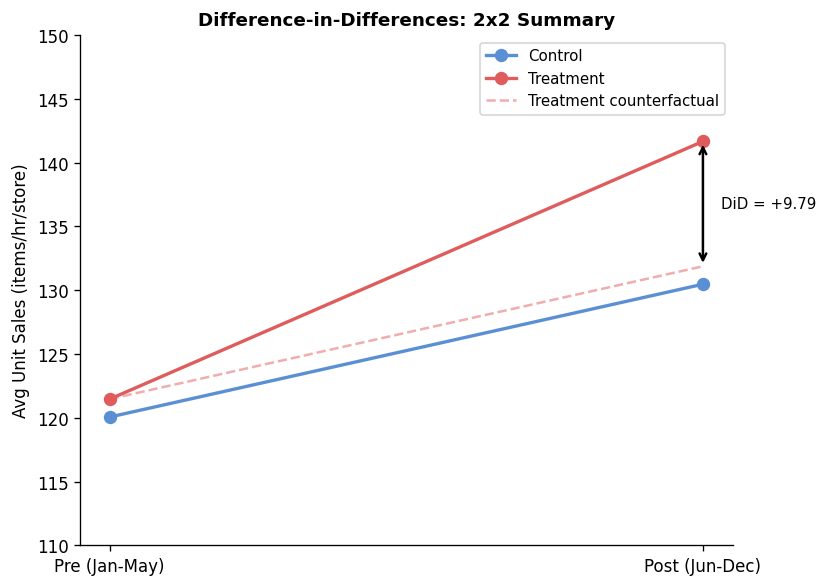

In [ ]:
# Visual: the 2x2 DiD
fig, ax = plt.subplots(figsize=(7, 5))

periods = ['Pre (Jan-May)', 'Post (Jun-Dec)']
ax.plot(periods, [ctrl_pre, ctrl_post], color='#5b8fd4', lw=2, marker='o', ms=7, label='Control')
ax.plot(periods, [trt_pre,  trt_post],  color='#e05c5c', lw=2, marker='o', ms=7, label='Treatment')

# Counterfactual: what treatment would have looked like without ads
counterfactual_post = trt_pre + (ctrl_post - ctrl_pre)
ax.plot(periods, [trt_pre, counterfactual_post],
        color='#e05c5c', lw=1.5, linestyle='--', alpha=0.5, label='Treatment counterfactual')

# Arrow showing DiD gap
ax.annotate('', xy=(1, trt_post), xytext=(1, counterfactual_post),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(1.03, (trt_post + counterfactual_post) / 2,
        f'DiD = +{did_est:.2f}', fontsize=9, va='center')

ax.set_ylabel('Avg Unit Sales (items/hr/store)')
ax.set_title('Difference-in-Differences: 2x2 Summary', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(110, 150)
plt.tight_layout()
plt.show()

In [ ]:
# Check on price, ads should not be affecting price if the effect is real
X_price = np.column_stack([
    np.ones(len(df)),
    df['treatment'],
    df['post'],
    df['treated_post']
])
res_price = ols_hc3(X_price, df['price'].values, ['intercept', 'treatment', 'post', 'treated_post'])

print("=== DiD on Price (placebo check) ===")
print(res_price.round(4).to_string())
print()
print(f"Price DiD estimate: {res_price.loc['treated_post','coef']:.4f}  (p={res_price.loc['treated_post','p']:.4f})")

=== DiD on Price (placebo check) ===
                coef      se        t       p
intercept     4.5027  0.0495  91.0241  0.0000
treatment    -0.2218  0.0703  -3.1553  0.0016
post          0.0926  0.0649   1.4284  0.1533
treated_post -0.0216  0.0920  -0.2344  0.8147

Price DiD estimate: -0.0216  (p=0.8147)


The interaction term on price is tiny and not significant (p=0.81).
The ads are drawing more customers in,
not changing what people pay per item. The sales effect is real volume, not a pricing artifact.

---
## Q.3 Should Starbucks implement more local search advertising on Google Maps?


The data shows that the ads generated a real, statistically significant lift in unit sales, roughly 9.79 additional items sold per hour per store during the ad period. The pre-period average was around 121 units per hour, so the ads produced roughly an 8% increase in sales volume.

However, a price check also matters here. The fact that prices did not change in treatment markets rules out the possibility that the effect is influenced by pricing.


In [ ]:
# Effect size in context
pre_avg = df[df['post'] == 0]['sales'].mean()
pct_lift = did_est / pre_avg * 100

print("=== Effect Size in Context ===")
print(f"Pre-period average sales:     {pre_avg:.2f} units/hr/store")
print(f"DiD estimate:                +{did_est:.2f} units/hr/store")
print(f"Percentage lift:             +{pct_lift:.1f}%")
print()

# Monthly breakdown: did the effect grow or stay flat?
post_monthly = df[df['post'] == 1].groupby(['month', 'treatment'])['sales'].mean().unstack()
post_monthly['diff'] = post_monthly[1] - post_monthly[0]
print("Monthly treatment - control gap (post-period):")
for m, row in post_monthly.iterrows():
    month_name = ['Jun','Jul','Aug','Sep','Oct','Nov','Dec'][m - 6]
    print(f"  {month_name}: {row['diff']:>+.2f}")

=== Effect Size in Context ===
Pre-period average sales:     120.76 units/hr/store
DiD estimate:                +9.79 units/hr/store
Percentage lift:             +8.1%

Monthly treatment - control gap (post-period):
  Jun: +9.48
  Jul: +11.71
  Aug: +10.73
  Sep: +16.65
  Oct: +9.72
  Nov: +11.43
  Dec: +8.65


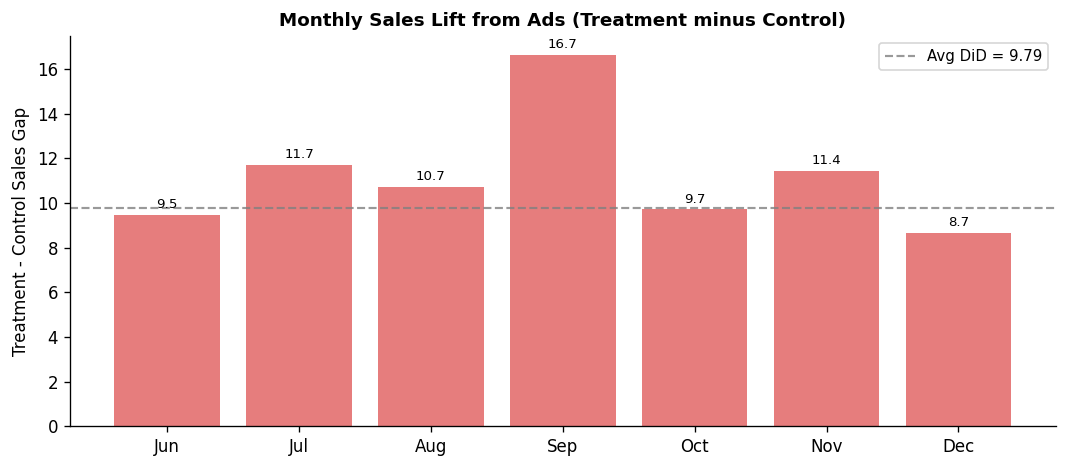

In [ ]:
# Visual: monthly treatment-control gap in the post period
fig, ax = plt.subplots(figsize=(9, 4))

post_df = df[df['post'] == 1].groupby(['month', 'treatment'])['sales'].mean().unstack().reset_index()
post_df['gap'] = post_df[1] - post_df[0]
month_names = ['Jun','Jul','Aug','Sep','Oct','Nov','Dec']

bars = ax.bar(month_names, post_df['gap'], color='#e05c5c', alpha=0.8)
ax.axhline(did_est, color='gray', lw=1.3, linestyle='--', alpha=0.8, label=f'Avg DiD = {did_est:.2f}')
ax.set_ylabel('Treatment - Control Sales Gap')
ax.set_title('Monthly Sales Lift from Ads (Treatment minus Control)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

for bar, val in zip(bars, post_df['gap']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


The gap grows over the course of the ad period: it starts at ~9 in June and reaches ~16 by September before settling back. This could mean the ads take a few months to build awareness, or that there are compounding effects.

Ultimately, the answer is yes. The ads produced a meaningful, statistically significant sales lift with no price distortion. The original concern that Starbucks was already so well-known that advertising would add nothing, turns out to be wrong, at least for this type of ad.
People already searching for "coffee shop" on Google Maps may have been funneled to competitors first. The ads will recapture that traffic.

The incremental cost of the ads would need to be weighed against the incremental revenue from ~9.79 extra units per hour per store, but the directional case for scaling up is strong.

## Q.4 If Phillips runs another test next year, should he set it up differently?

Yes, there are a couple things that would make the test more solid:

Run ads for the full year, not just 7 months. The current design confounds the treatment effect with seasonality, the ad period overlaps entirely with the second half of the year, which is when sales trend upward anyway. Even though DiD controls for overall time trends, the parallel trends assumption is harder to defend if the post-period is different from the pre-period in ways beyond just the ads (e.g., holiday promotions, back-to-school traffic).

Track more than just sales and price. The dataset tells us sales went up but not why, there could be other reasons beyond what is seen here. Are these new customers coming in for the first time, or existing customers visiting more frequently? If it were the second option, the ROI picture looks different, those customers might have come anyway and the ads just accelerated the visit. Adding visit frequency, new vs. returning customer breakdown, or loyalty program enrollment would make the mechanism visible.

Testing additional keywords beyond just "coffee shop". The current test only
covers one keyword. There are different ways customers could be looking for the coffee shop. "espresso near me" or "iced coffee" for example, might convert at different rates. Understanding which keywords drive the most lift per dollar spent could also help optimize the ad budget before a full rollout.

Considering more longer-run effects. The treatment period is 7 months, and the monthly breakdown shows the gap growing over time. It's possible the effect is still building at the end of December. A follow-up measurement period after ads are turned off would show whether sales hold or revert, which tells you whether the ads are building habit or just capturing in-the-moment demand.